In [1]:
!pip install matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('final_internship_data.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  str    
 1   User Name          500000 non-null  str    
 2   Driver Name        500000 non-null  str    
 3   Car Condition      500000 non-null  str    
 4   Weather            500000 non-null  str    
 5   Traffic Condition  500000 non-null  str    
 6   key                500000 non-null  str    
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  str    
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  month        

In [5]:
df.sort_values(by='fare_amount', ascending=False).head(10)

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
101885,fQUfaZnP,Hector Christensen,Deborah Lopez,Excellent,cloudy,Dense Traffic,2011-09-12 09:33:56.0000004,500.00,2011-09-12 09:33:56,-1.290950,...,9,0,2011,31.569506,36.080529,34.223401,17.098820,17.725520,0.000000,0.000000
247671,DqkM7wCl,Robert Jones,Melissa Delgado,Bad,windy,Dense Traffic,2015-05-12 13:16:47.0000004,495.00,2015-05-12 13:16:47,-1.288313,...,5,1,2015,146.783965,199.496128,153.230146,178.952005,172.019797,140.514983,-1.311548
233874,qbAt4ql5,David Simpson,Laura Callahan,Excellent,cloudy,Dense Traffic,2012-10-28 14:14:44.0000001,450.00,2012-10-28 14:14:44,-1.290357,...,10,6,2012,43.283581,46.328539,10.701157,30.669990,22.371531,0.692212,-0.352223
329010,KR0Z0jiz,Michael Turner,David Nichols,Very Good,rainy,Dense Traffic,2011-07-29 14:19:00.000000200,450.00,2011-07-29 14:19:00,-1.290765,...,7,4,2011,48.208327,44.464294,15.755432,30.837837,23.044911,0.001448,-0.058156
287638,zZc1yUy9,Karen Vance,Benjamin Mason,Very Good,windy,Congested Traffic,2015-03-11 16:25:21.0000007,450.00,2015-03-11 16:25:21,-1.289956,...,3,2,2015,37.702531,47.665372,6.129970,30.131293,21.639273,0.001973,-1.787437
361793,bod5GFNY,Heather Martinez,Christopher Colon,Very Good,rainy,Congested Traffic,2011-05-05 08:39:00.00000018,400.00,2011-05-05 08:39:00,-1.288972,...,5,3,2011,58.751448,70.117880,27.046403,56.549514,48.369952,0.001307,2.443013
451974,0aEc5GnQ,Philip Sharp Jr.,Teresa Williams,Excellent,sunny,Dense Traffic,2011-10-08 05:17:04.0000002,400.00,2011-10-08 05:17:04,-1.290561,...,10,5,2011,31.681412,38.083469,19.489431,17.512281,10.658353,0.008944,-0.103856
130460,fShA0Q7b,Christopher Brandt,Cameron Ellis,Good,cloudy,Congested Traffic,2012-09-01 13:24:00.000000160,281.05,2012-09-01 13:24:00,-1.287874,...,9,5,2012,87.027624,139.808482,97.935375,121.065758,114.637441,86.299253,-0.744047
309769,j4DWt39W,Deborah Levy,Dennis Howell,Bad,windy,Congested Traffic,2014-05-19 10:11:10.0000001,263.25,2014-05-19 10:11:10,-1.298646,...,5,0,2014,111.943207,62.204087,111.912623,76.984270,85.461106,0.015589,-1.890037
142550,AgQBdoSP,Raymond Meza,Robin Larsen,Good,cloudy,Congested Traffic,2012-10-30 20:38:00.00000095,255.00,2012-10-30 20:38:00,-1.290127,...,10,1,2012,32.794721,43.507050,11.049822,24.213582,15.993772,0.107639,3.039667


## **ohh**
As shown from this cell below there is some weird values shown in **min** row such as :
- negative values in fare_amount
- zero distance
- zero passenger count

### we will clean it very soon 

In [6]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


In [7]:
df = df.drop(columns=['User ID', 'User Name', 'Driver Name'])

## by making sure all the trips in the dataset are unique , now i can drop the keys column

In [8]:
print(len(df))
print(df['key'].nunique())

500000
500000


In [9]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour_check']    = df['pickup_datetime'].dt.hour
df['weekday_check'] = df['pickup_datetime'].dt.dayofweek   
df['day_check']     = df['pickup_datetime'].dt.day         
df['month_check']   = df['pickup_datetime'].dt.month

In [10]:
print((df['hour'] == df['hour_check']).mean())
print((df['weekday'] == df['weekday_check']).mean())
print((df['day'] == df['day_check']).mean())
print((df['month'] == df['month_check']).mean())

1.0
1.0
1.0
1.0


In [11]:
df = df.drop(columns=['hour_check', 'weekday_check', 'day_check', 'month_check'])

In [12]:
# Check how many rows are affected by each issue before removing anything
print("Zero passengers:", (df['passenger_count'] == 0).sum())
print("Zero distance:", (df['distance'] == 0).sum())
print("Negative or zero fare:", (df['fare_amount'] <= 0).sum())

Zero passengers: 1796
Zero distance: 14250
Negative or zero fare: 35


In [13]:
# Cleaning by removing logically impossible values
df = df[df['passenger_count'] > 0]
df = df[df['distance'] > 0]
df = df[(df['fare_amount'] > 1) & (df['fare_amount'] < 200)]

print("Remaining rows:", len(df))

Remaining rows: 483921


## Q1: Is higher Passengers means higher price?

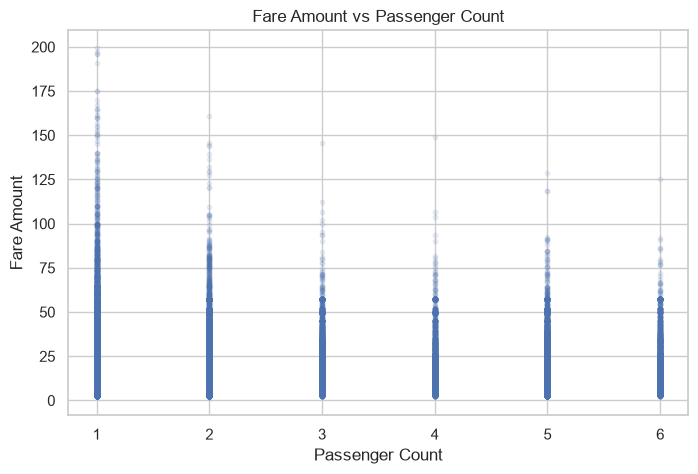

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df['passenger_count'], df['fare_amount'], alpha=0.1, s=10)
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Passenger Count')
plt.show()

There's no clear upward trend in fare as passenger count increases — the distribution of fares looks almost identical whether there's 1 passenger or 6. This makes sense because Uber prices rides by distance, time and Car type maybe, not by number of riders.

## note :
the plot shows some price outliers so i fix that deleting any price above 200 dollars 

### when talking about outliers , i notice outliers in coordinates so i converted it into degrees then clean it as shown below

In [15]:
for col in ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']:
    df[col] = np.degrees(df[col])

df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,483921.000000,483921.000000,483921.000000,483921.000000
mean,-73.848647,40.650803,-73.851083,40.646846
std,6.750612,6.093775,6.642313,5.122289
min,-2986.242495,-3116.285383,-3383.296608,-2559.748913
25%,-73.992260,40.736462,-73.991557,40.735482
50%,-73.982083,40.753338,-73.980575,40.753837
75%,-73.968372,40.767456,-73.965282,40.768402
max,2140.601160,1703.092772,40.851027,404.616667


In [16]:
total_rows = len(df)

valid_mask = (df['pickup_longitude'].between(-75, -72)) & \
             (df['pickup_latitude'].between(40, 42)) & \
             (df['dropoff_longitude'].between(-75, -72)) & \
             (df['dropoff_latitude'].between(40, 42))

valid_rows = valid_mask.sum()
invalid_rows = total_rows - valid_rows

print("Total rows:", total_rows)
print("Valid NYC-coordinate rows:", valid_rows)
print("Invalid rows (would be dropped):", invalid_rows)
print("Percentage invalid:", round(invalid_rows / total_rows * 100, 2), "%")

Total rows: 483921
Valid NYC-coordinate rows: 482519
Invalid rows (would be dropped): 1402
Percentage invalid: 0.29 %


In [17]:
df = df[valid_mask]
print(len(df))

482519


In [18]:
df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,482519.000000,482519.000000,482519.000000,482519.000000
mean,-73.975457,40.750936,-73.974480,40.751323
std,0.036434,0.028237,0.035707,0.031559
min,-74.968142,40.052722,-74.964263,40.041180
25%,-73.992275,40.736573,-73.991572,40.735630
50%,-73.982103,40.753396,-73.980615,40.753900
75%,-73.968475,40.767491,-73.965428,40.768425
max,-72.702870,41.800252,-72.694838,41.923820


## Q2: Does car condition influence the fare amount? 

In [19]:
df.groupby('Car Condition')['fare_amount'].mean()

Car Condition
Bad          11.300933
Excellent    11.332962
Good         11.331167
Very Good    11.393993
Name: fare_amount, dtype: float64

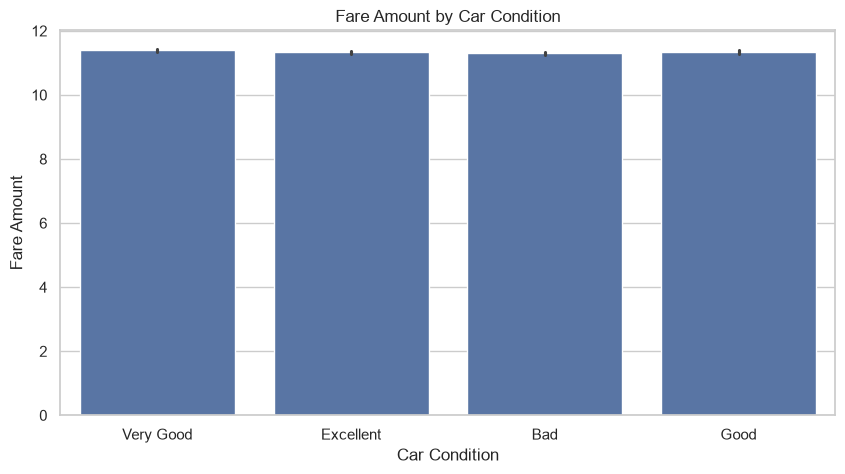

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(x='Car Condition', y='fare_amount', data=df)
plt.xlabel('Car Condition')
plt.ylabel('Fare Amount')
plt.title('Fare Amount by Car Condition')
plt.show()

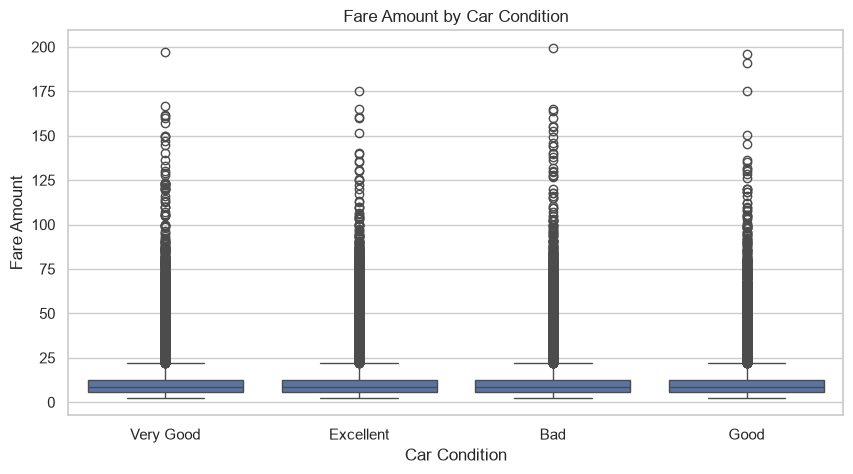

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Car Condition', y='fare_amount', data=df)
plt.xlabel('Car Condition')
plt.ylabel('Fare Amount')
plt.title('Fare Amount by Car Condition')
plt.show()

As shown the car condition doesn't affect the price , we try two graph options + calculating means and all state this insight 

## Q3: At what hour of the day are fares typically highest?  

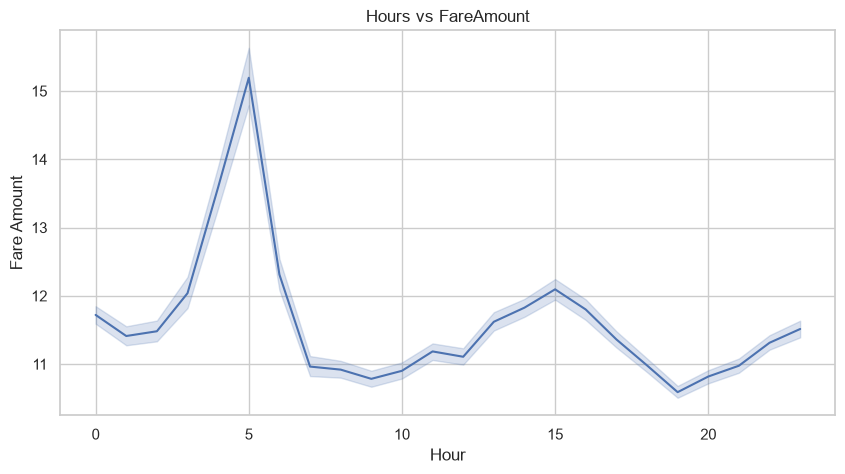

In [22]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='fare_amount', data=df)
plt.xlabel('Hour')
plt.ylabel('Fare Amount')
plt.title('Hours vs FareAmount')
plt.show()

In [23]:
df.groupby('hour')['fare_amount'].mean()

hour
0     11.720350
1     11.411246
2     11.480791
3     12.038084
4     13.590748
5     15.194058
6     12.311050
7     10.963475
8     10.918879
9     10.783901
10    10.901368
11    11.185435
12    11.107233
13    11.619893
14    11.826569
15    12.095006
16    11.799638
17    11.361454
18    10.980894
19    10.588877
20    10.817702
21    10.975846
22    11.312243
23    11.513903
Name: fare_amount, dtype: float64

## Q4: Does traffic condition affect the trip fare?

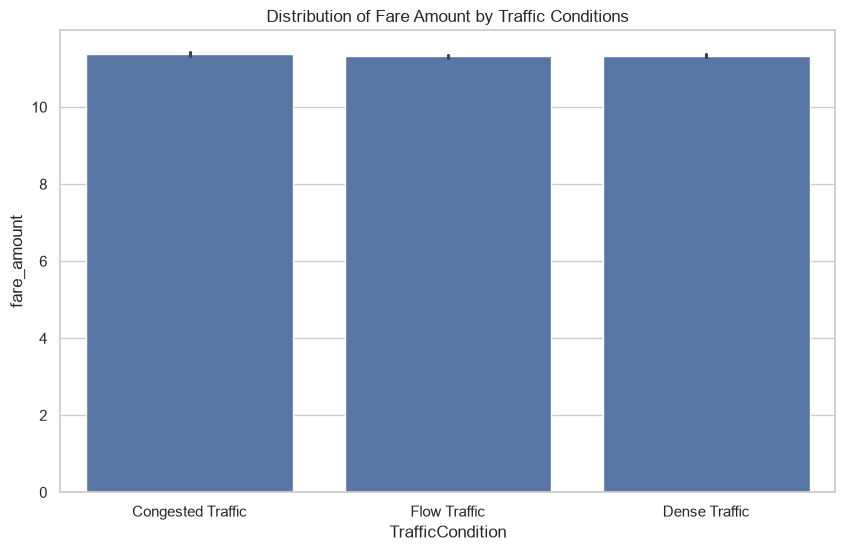

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(x='Traffic Condition', y='fare_amount', data=df)
plt.xlabel('TrafficCondition')
plt.ylabel('fare_amount')
plt.title('Distribution of Fare Amount by Traffic Conditions')

plt.show()

In [25]:
df.groupby('Traffic Condition')['fare_amount'].mean()

Traffic Condition
Congested Traffic    11.373387
Dense Traffic        11.333844
Flow Traffic         11.312094
Name: fare_amount, dtype: float64

### the traffic is not affecting the fare_amount seems that they agree on it before the ride 

## Q5: Is trip distance the strongest predictor of the fare amount? 

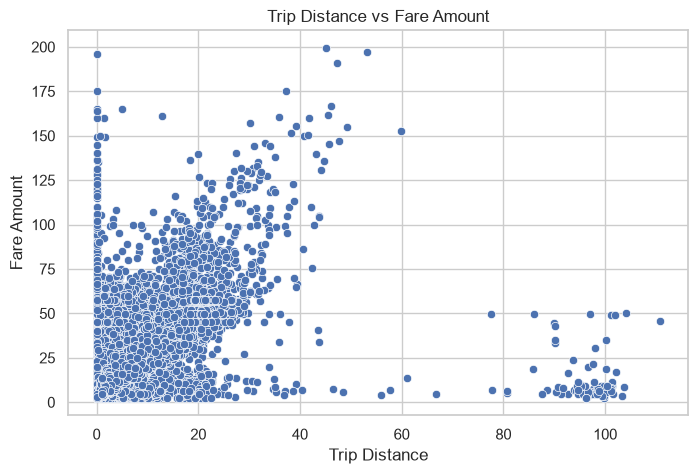

In [26]:
# before plotting we can expect that yes it must be # Set the figure size
plt.figure(figsize=(8, 5))

# Create the scatter plot
sns.scatterplot(x='distance', y='fare_amount', data=df)
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount')
plt.show()


In [27]:
# Calculate the numerical correlation
correlation = df['distance'].corr(df['fare_amount'])
print(f"Correlation Coefficient: {correlation:.4f}")

Correlation Coefficient: 0.8310


## As expected, correlation function and linear increase shown in scatter plot both emphazies on the relation between price and distance 

## Q6: At what time of day are ride requests most frequent?

In [28]:
df['hour'].value_counts().sort_index()

hour
0     18941
1     14040
2     10487
3      7632
4      5631
5      4783
6      9982
7     17582
8     21836
9     22789
10    21668
11    22549
12    23783
13    23529
14    24508
15    23200
16    19830
17    23762
18    29026
19    30278
20    28237
21    27618
22    26839
23    23989
Name: count, dtype: int64

C:\Users\mocam\AppData\Local\Temp\ipykernel_41252\798300682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='plasma')


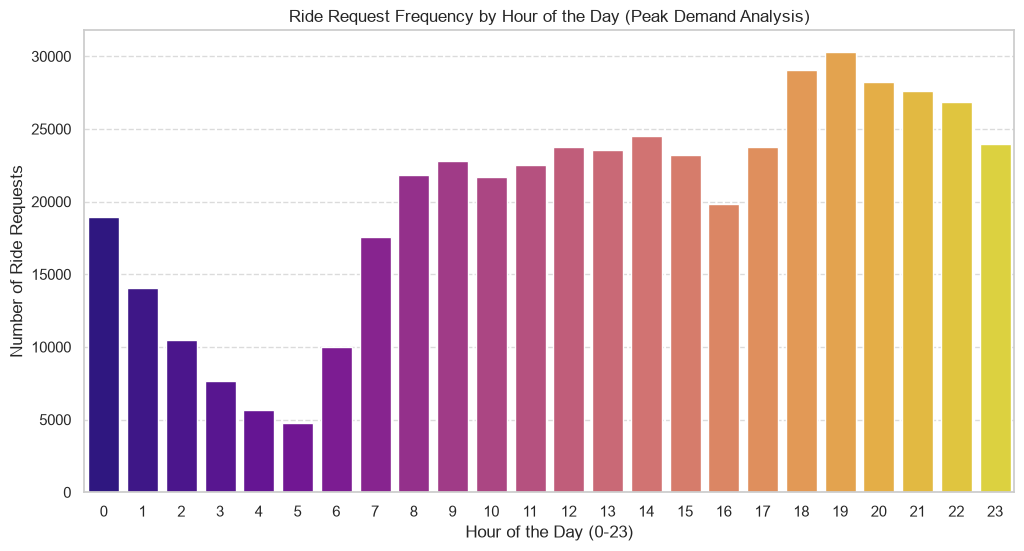

In [29]:
plt.figure(figsize=(12, 6))

sns.countplot(x='hour', data=df, palette='plasma')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Ride Requests')
plt.title('Ride Request Frequency by Hour of the Day (Peak Demand Analysis)')

# Add a grid along the Y-axis to make reading the counts easier
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Good , the numerical and graphical solutions agrees that 7 PM is the rush request hour 

## Q7: Does weather condition influence the average trip distance?

In [30]:
df.groupby('Weather')['distance'].mean().sort_values(ascending=False)

Weather
sunny     3.383118
stormy    3.375113
cloudy    3.371883
windy     3.367508
rainy     3.362721
Name: distance, dtype: float64

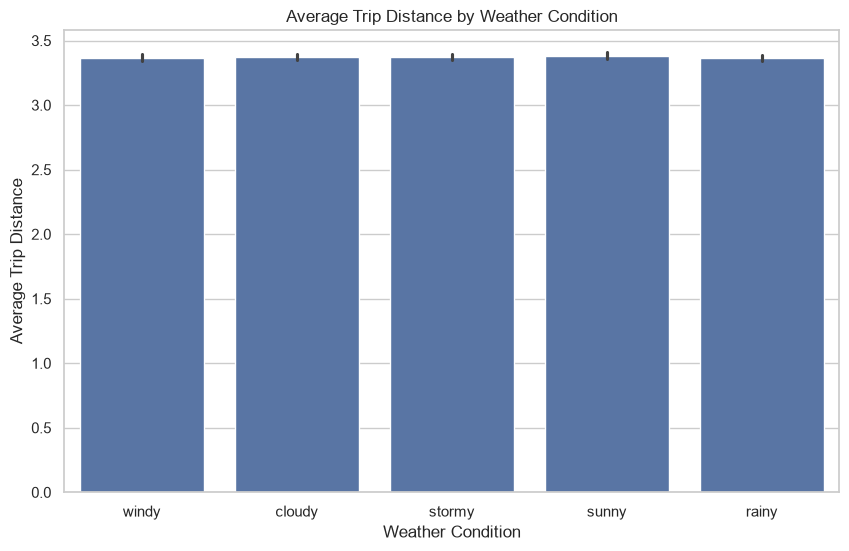

In [31]:
# the means said that no effect , let's make sure by Barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Weather',y='distance',data=df)
plt.xlabel('Weather Condition')
plt.ylabel('Average Trip Distance')
plt.title('Average Trip Distance by Weather Condition')
plt.show()

In [32]:
# 1. Create a temporary dataframe with 0 and 1 columns for each weather type
weather_encoded = pd.get_dummies(df[['Weather', 'distance']], columns=['Weather'])

# 2. Calculate correlation across this new dataframe
weather_corr = weather_encoded.corr()['distance'].sort_values(ascending=False)

print("Correlation of each weather type with distance:")
print(weather_corr)

Correlation of each weather type with distance:
distance          1.000000
Weather_sunny     0.001461
Weather_stormy    0.000400
Weather_cloudy   -0.000026
Weather_windy    -0.000602
Weather_rainy    -0.001236
Name: distance, dtype: float64


### OK , Weather has absolutely no effect on distance  

## Q8: Are rides that start closer to airports generally more expensive?

In [33]:
df.head(10)

,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-73.844311,40.721319,-73.841610,40.712278,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-74.016048,40.711303,-73.979268,40.782004,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-73.982738,40.761270,-73.991242,40.750562,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-73.987130,40.733143,-73.991567,40.758092,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-73.968095,40.768008,-73.956655,40.783762,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703
5,Excellent,sunny,Congested Traffic,2011-01-06 09:50:45.0000002,12.1,2011-01-06 09:50:45,-74.000964,40.731630,-73.972892,40.758233,...,1,3,2011,42.335622,32.824930,20.648176,15.741133,7.649541,3.787239,-0.674251
6,Excellent,windy,Flow Traffic,2012-11-20 20:35:00.0000001,7.5,2012-11-20 20:35:00,-73.980002,40.751662,-73.973802,40.764842,...,11,1,2012,42.563234,35.482608,18.113693,19.126670,10.993150,1.555807,-0.342260
7,Good,sunny,Congested Traffic,2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00,-73.951300,40.774138,-73.990095,40.751048,...,1,2,2012,42.533214,36.829343,16.949505,20.548489,12.449213,4.155444,2.236596
8,Excellent,rainy,Dense Traffic,2012-12-03 13:10:00.000000125,9.0,2012-12-03 13:10:00,-74.006462,40.726713,-73.993078,40.731628,...,12,0,2012,42.240568,29.608237,23.942272,11.667601,3.637447,1.253232,-1.119470
9,Very Good,sunny,Dense Traffic,2009-09-02 01:11:00.00000083,8.9,2009-09-02 01:11:00,-73.980658,40.733873,-73.991540,40.758138,...,9,2,2009,42.218767,33.106804,20.538553,16.193381,8.129651,2.849627,0.327463


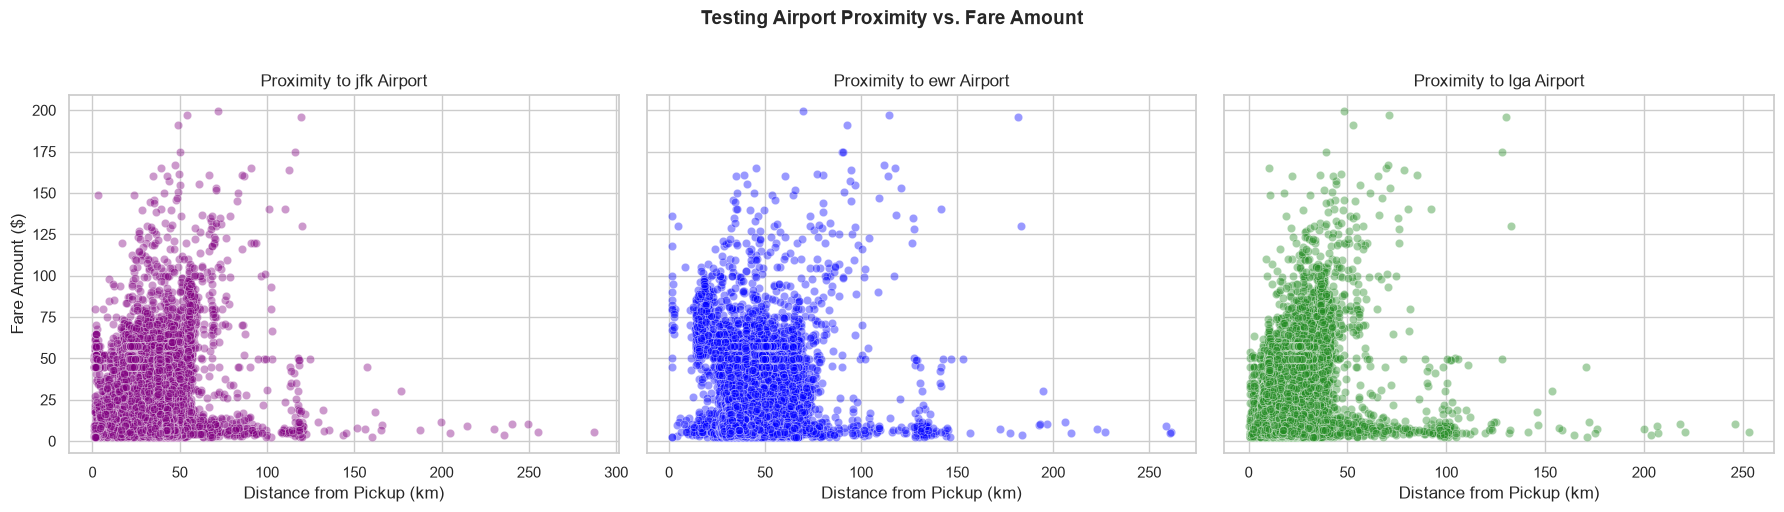

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a side-by-side layout for the 3 airports
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)


airports = ['jfk_dist', 'ewr_dist', 'lga_dist']
colors = ['purple', 'blue', 'forestgreen']

# Loop through and build a pure scatter plot for each airport
for i, airport in enumerate(airports):
    sns.scatterplot(
        ax=axes[i],
        x=airport,
        y='fare_amount',  
        data=df,
        alpha=0.4,        
        color=colors[i]
    )
    axes[i].set_title(f'Proximity to {airport.split("_")[0]} Airport')
    axes[i].set_xlabel('Distance from Pickup (km)')
    
    if i == 0:
        axes[i].set_ylabel('Fare Amount ($)')

plt.suptitle('Testing Airport Proximity vs. Fare Amount', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## The Insight:
### for jfk airport we can say that requesting a ride near the airport is somehow increase the Fare but we can't generalize that on all airports as shown  

In [35]:
df.info()

<class 'pandas.DataFrame'>
Index: 482519 entries, 0 to 499999
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Car Condition      482519 non-null  str           
 1   Weather            482519 non-null  str           
 2   Traffic Condition  482519 non-null  str           
 3   key                482519 non-null  str           
 4   fare_amount        482519 non-null  float64       
 5   pickup_datetime    482519 non-null  datetime64[us]
 6   pickup_longitude   482519 non-null  float64       
 7   pickup_latitude    482519 non-null  float64       
 8   dropoff_longitude  482519 non-null  float64       
 9   dropoff_latitude   482519 non-null  float64       
 10  passenger_count    482519 non-null  int64         
 11  hour               482519 non-null  int64         
 12  day                482519 non-null  int64         
 13  month              482519 non-null  int64         
 14  week

##  New Questions for understand the data 

now we have more 7 questions will help us get more insights about the dataset 

## Q9: What is Total fare revenue by month?

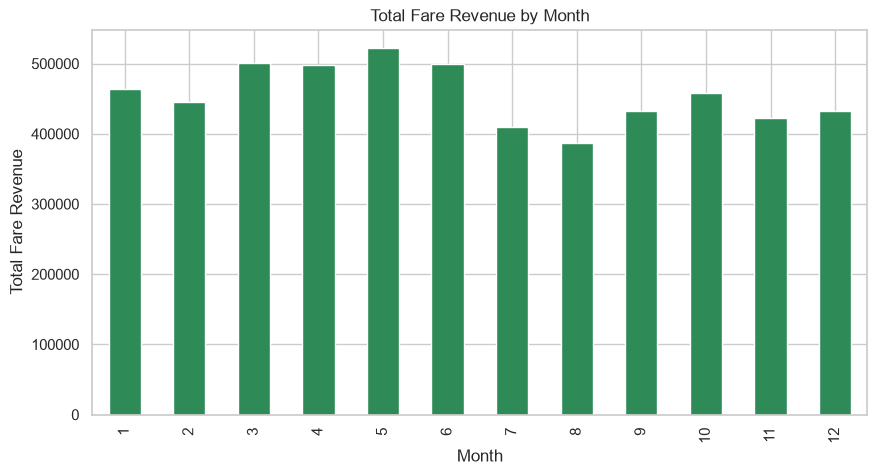

In [36]:
monthly_revenue = df.groupby('month')['fare_amount'].sum()
plt.figure(figsize=(10,5))
monthly_revenue.plot(kind='bar', color='seagreen')
plt.xlabel('Month')
plt.ylabel('Total Fare Revenue')
plt.title('Total Fare Revenue by Month')
plt.show()

               sum       mean   count
season                               
Fall    1312684.31  11.666438  112518
Spring  1521515.93  11.335563  134225
Summer  1295626.52  11.303669  114620
Winter  1341840.89  11.075315  121156


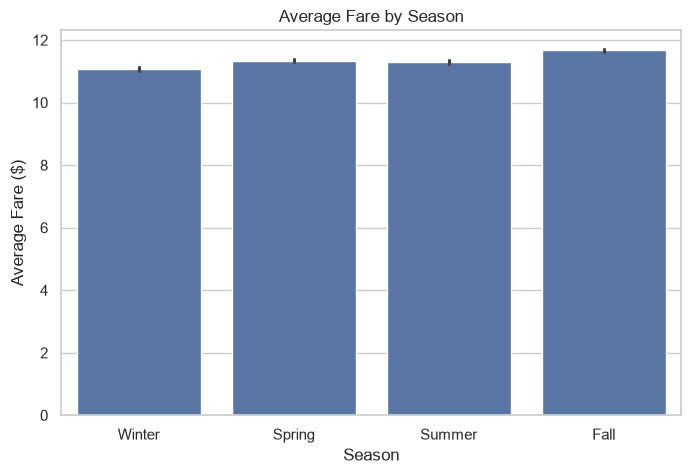

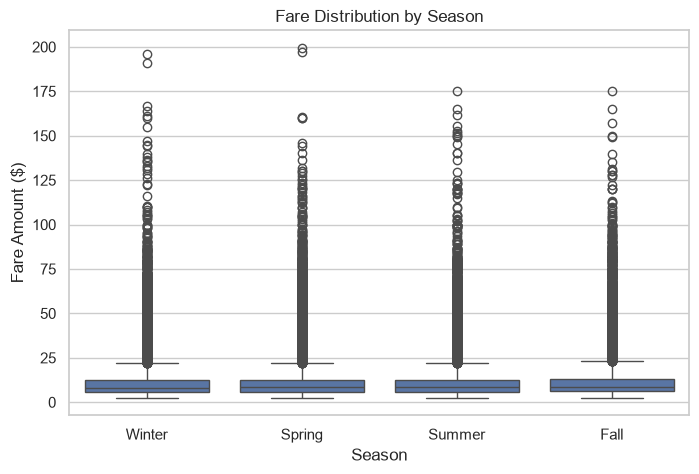

In [37]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Fall'

df['season'] = df['month'].apply(get_season)

# Total and average revenue by season
print(df.groupby('season')['fare_amount'].agg(['sum', 'mean', 'count']))

# Visual comparison
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='season', y='fare_amount', data=df, estimator='mean',
            order=['Winter','Spring','Summer','Fall'])
plt.xlabel('Season')
plt.ylabel('Average Fare ($)')
plt.title('Average Fare by Season')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='season', y='fare_amount', data=df,
            order=['Winter','Spring','Summer','Fall'])
plt.xlabel('Season')
plt.ylabel('Fare Amount ($)')
plt.title('Fare Distribution by Season')
plt.show()

## The Insight:
### Uber are operating in a steady way across the year and across the seasons with a slight victory for spring 

## Q10:  Holiday vs non-holiday passenger count ?

In [38]:
!pip install holidays

In [39]:
print(sorted(df['year'].unique()))

[np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]


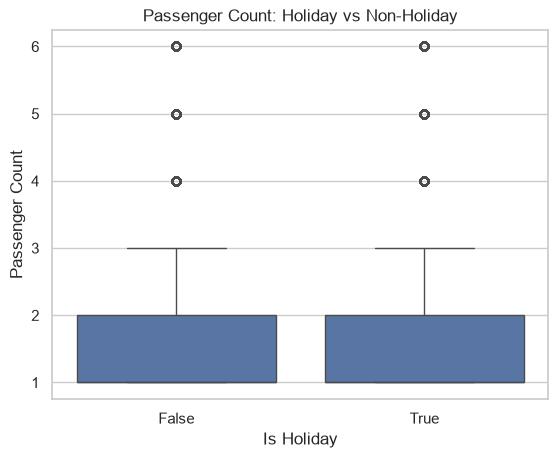

In [40]:
import holidays
us_holidays = holidays.US(years=[2009,2010,2011,2012,2013,2014,2015]) 
df['is_holiday'] = df['pickup_datetime'].dt.date.isin(us_holidays)

sns.boxplot(x='is_holiday', y='passenger_count', data=df)
plt.xlabel('Is Holiday')
plt.ylabel('Passenger Count')
plt.title('Passenger Count: Holiday vs Non-Holiday')
plt.show()

In [41]:
holiday_counts = df.groupby('is_holiday').size()
print(holiday_counts)

# Number of distinct holiday days vs non-holiday days in your data range
num_holiday_days = df[df['is_holiday']]['pickup_datetime'].dt.date.nunique()
num_nonholiday_days = df[~df['is_holiday']]['pickup_datetime'].dt.date.nunique()

# Average rides PER DAY for each group — this is the fair comparison
avg_requests_holiday = holiday_counts[True] / num_holiday_days
avg_requests_nonholiday = holiday_counts[False] / num_nonholiday_days

print("Average rides per holiday day:", avg_requests_holiday)
print("Average rides per non-holiday day:", avg_requests_nonholiday)

is_holiday
False    471473
True      11046
dtype: int64
Average rides per holiday day: 155.57746478873239
Average rides per non-holiday day: 204.89917427205563


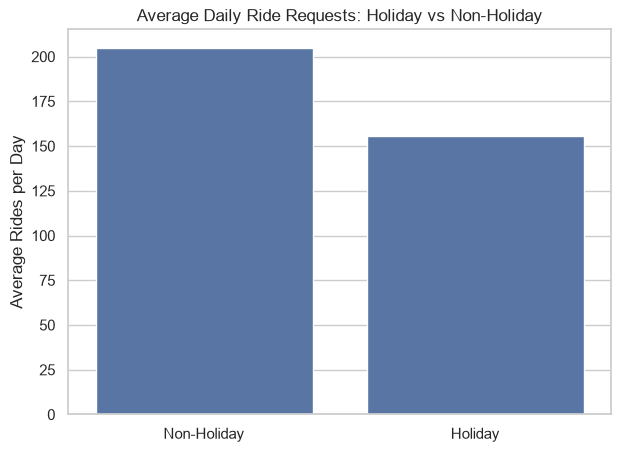

In [42]:
plt.figure(figsize=(7,5))
sns.barplot(x=['Non-Holiday', 'Holiday'], y=[avg_requests_nonholiday, avg_requests_holiday])
plt.ylabel('Average Rides per Day')
plt.title('Average Daily Ride Requests: Holiday vs Non-Holiday')
plt.show()

## Q11: Distribution of passenger count (solo vs group rides)

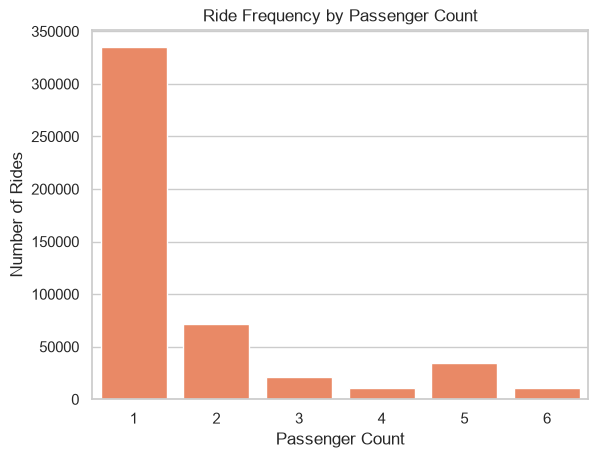

In [43]:
sns.countplot(x='passenger_count', data=df, color='coral')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Rides')
plt.title('Ride Frequency by Passenger Count')
plt.show()

## The Insight:
### The data clearly indicates that solo rides (1 passenger) are by far the most frequent event in this dataset, demonstrating that single commuters drive peak demand.

## Q12: Month with most expensive average fare?

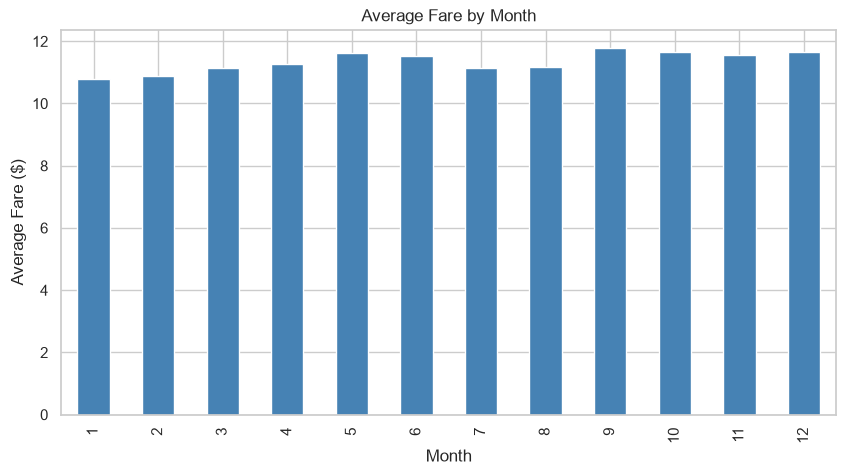

In [44]:
monthly_avg_fare = df.groupby('month')['fare_amount'].mean()
plt.figure(figsize=(10,5))
monthly_avg_fare.plot(kind='bar', color='steelblue')
plt.xlabel('Month')
plt.ylabel('Average Fare ($)')
plt.title('Average Fare by Month')
plt.show()

## Q13: Car condition vs passenger count

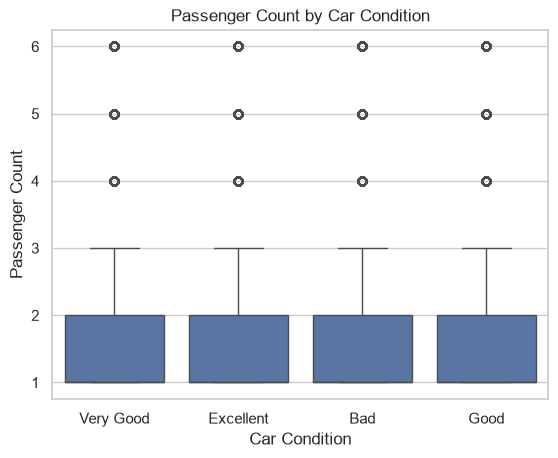

In [45]:
sns.boxplot(x='Car Condition', y='passenger_count', data=df)
plt.xlabel('Car Condition')
plt.ylabel('Passenger Count')
plt.title('Passenger Count by Car Condition')
plt.show()

Car Condition
Very Good    120888
Bad          120625
Good         120577
Excellent    120429
Name: count, dtype: int64


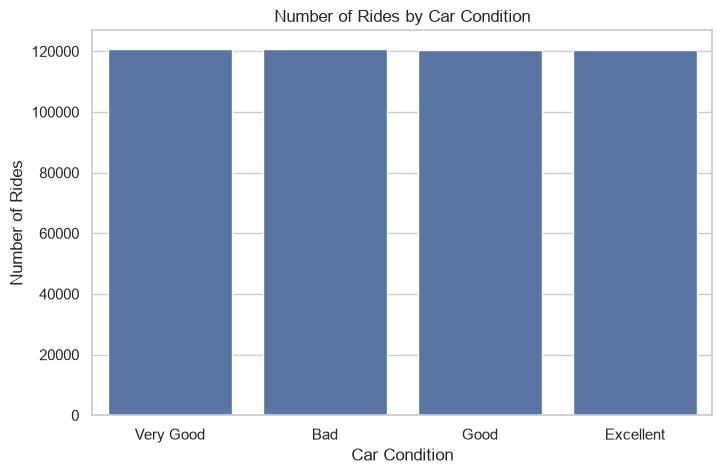

In [46]:
print(df['Car Condition'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='Car Condition', data=df, order=df['Car Condition'].value_counts().index)
plt.xlabel('Car Condition')
plt.ylabel('Number of Rides')
plt.title('Number of Rides by Car Condition')
plt.show()

## The Insight:
### each graph here answer different question the boxplot answer if the company made good condtion cars for more number of passengers per ride or all is same , but unfortunalty the distriubution are very uniform , for the second gragh we answer if the good condtion cars get more requests in general and the answer is also NO 

## Q14: Fare amount trend across years?

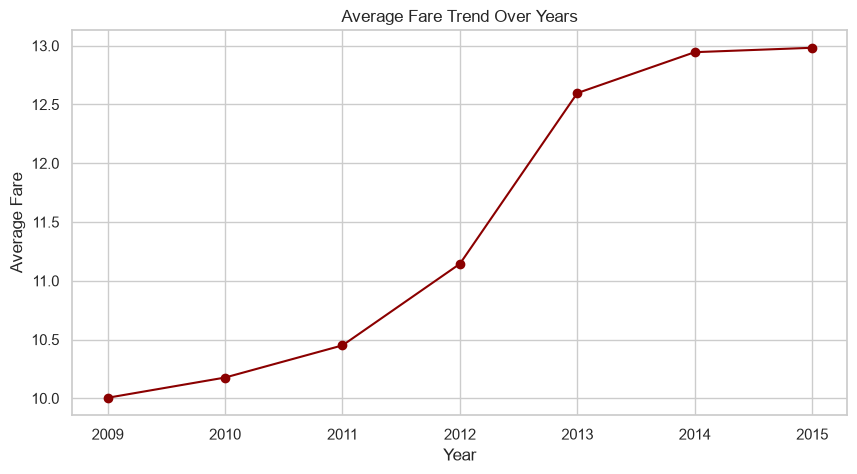

In [47]:
yearly_avg_fare = df.groupby('year')['fare_amount'].mean()
plt.figure(figsize=(10,5))
yearly_avg_fare.plot(kind='line', marker='o', color='darkred')
plt.xlabel('Year')
plt.ylabel('Average Fare')
plt.title('Average Fare Trend Over Years')
plt.show()

## The Insight:
### As Expected Fair amount increase with years because of inflation, but why this jump from 2012 to 2013 ?

## Q15: Correlation heatmap: which features relate most to fare?

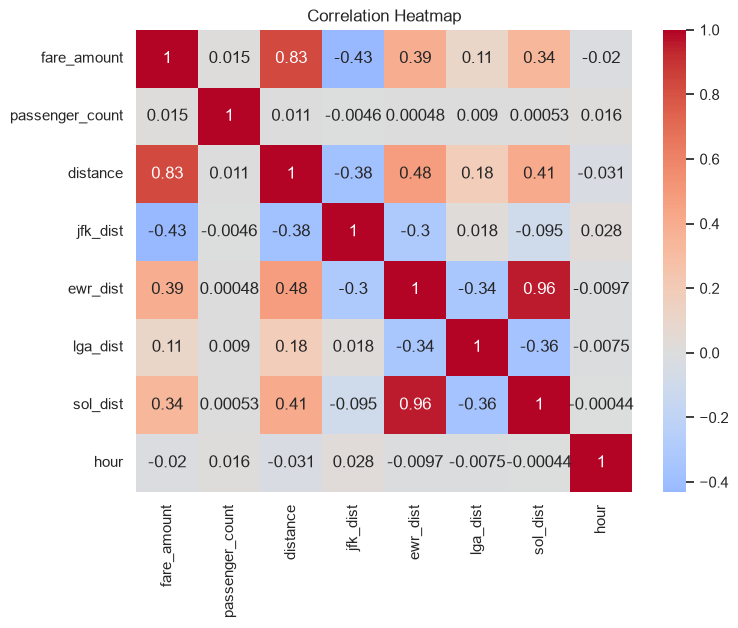

In [48]:
numeric_cols = ['fare_amount','passenger_count','distance','jfk_dist','ewr_dist','lga_dist','sol_dist','hour']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

**The last plot in our Notebook summarized a lot of features relations with each other which tell that the strongest relation that we have to take it into consideration when training our machine learing model is the relation between distance and fare because the rest is not that strong**